# Part 1
Implement the face-recognition algorithm as described in Lecture based on the concept of Sparse Representation Classiﬁcation (SRC).

The database that we will use to evaluate the performance of your algorithms is the Extended Yale Face Database B which contains 38 human subjects under diﬀerent poses and illumination conditions. o reduce the computational complexity, we will only experiment with the cropped database whose images have been manually aligned, cropped, and then re-sized to 96 × 84. This database can be downloaded from Canvas as a mat ﬁle.

In [3]:
# This part is for running on Google Colab, if you are running this locally, comment it out
%cd /content/COMP5340_compressed_sensing/homeworks/notebooks
!pip install batched_omp -q

/content/COMP5340_compressed_sensing/homeworks/notebooks


In [4]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from tqdm import tqdm

from HW2 import solve_l1_linear_programming, solve_orthogonal_matching_pursuit, plot_solution

In [5]:
# Load the data from .mat files
DATA_FILE_PATH = '../data/CroppedYale_96_84_2414_subset.mat'

data = loadmat(DATA_FILE_PATH)

print("Data loaded successfully!")
print(data.keys())  # Print the keys to understand the structure of the loaded data

Data loaded successfully!
dict_keys(['__header__', '__version__', '__globals__', 'sizeim', 'faces', 'facecls', 'facesubset'])


In [6]:
print(data['faces'].shape)
print(data['facecls'].shape)
print(data['facesubset'].shape) # 5 different subsets

(2414, 96, 84)
(2414, 1)
(2414, 1)


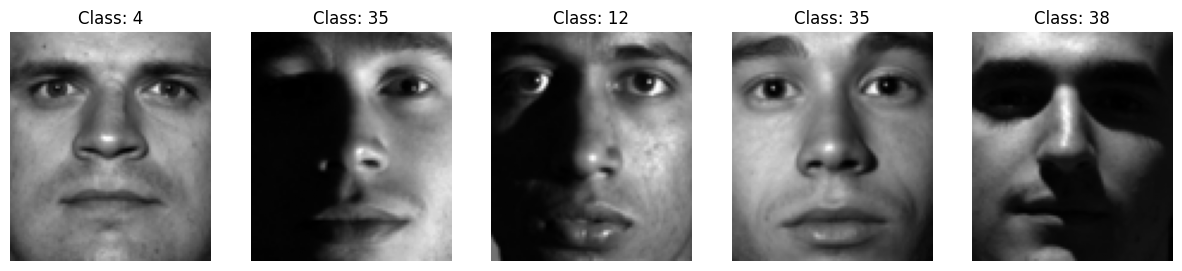

In [7]:
# Visualize some sample images from the dataset
num_samples = 5
plt.figure(figsize=(15, 3))
for i in range(num_samples):
    id  = np.random.randint(0, data['faces'].shape[0])  # Randomly select an index
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(data['faces'][id, :, :], cmap='gray')
    plt.title(f"Class: {data['facecls'][id][0]}")
    plt.axis('off')
plt.show()

In [8]:
# Split the data into training and testing sets
train_subsets = [0, 1, 2]  # Use subsets 0, 1, and 2 for training
test_subsets = [3, 4]  # Use subsets 3 and 4 for testing

train_indices = np.isin(data['facesubset'], train_subsets).flatten()
test_indices = np.isin(data['facesubset'], test_subsets).flatten()

X_train = data['faces'][train_indices, :, :]
y_train = data['facecls'][train_indices].flatten()
X_test = data['faces'][test_indices, :, :]
y_test = data['facecls'][test_indices].flatten()

In [9]:
y_train[:30], y_test[:30]  # Print the first 10 labels of training and testing sets

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1], dtype=uint8),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2], dtype=uint8))

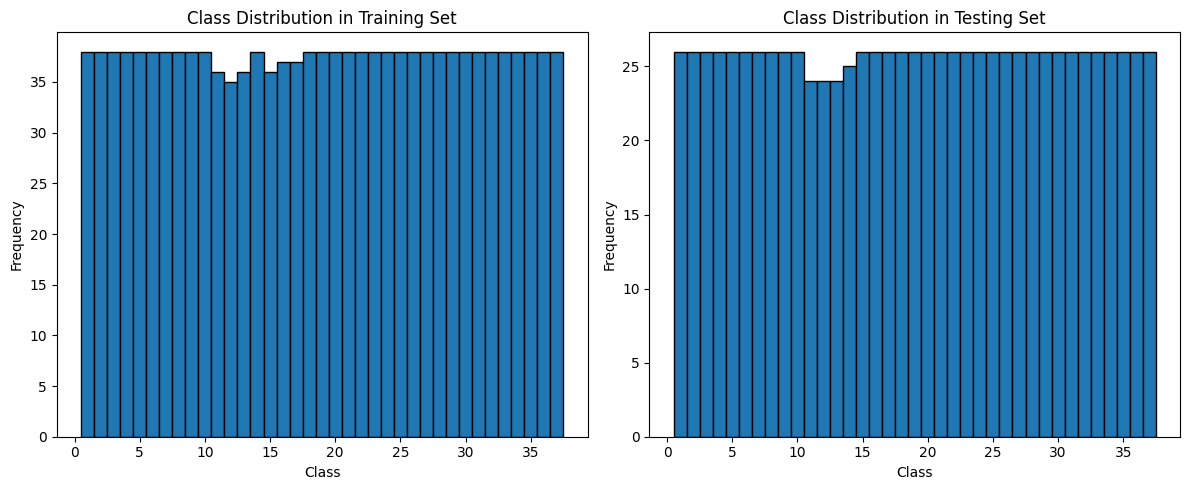

In [10]:
# Plot the distribution of classes in the training and testing sets
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=np.arange(1, 39) - 0.5, edgecolor='black')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=np.arange(1, 39) - 0.5, edgecolor='black')
plt.title('Class Distribution in Testing Set')
plt.xlabel('Class')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
# Build a dictionary for sparse representation

# For simplicity, we will use the training images as the dictionary
# Each column of the dictionary will be a vectorized training image

num_train_samples = X_train.shape[0]
num_features = X_train.shape[1] * X_train.shape[2]  # Assuming grayscale images
dictionary = X_train.reshape(num_train_samples, -1).T  # Shape: (num_features, num_train_samples)

In [12]:
# Perform classification one test image using sparse recovery methods (L1 minimization and OMP)
test_image = X_test[0, :, :].flatten()  # Vectorize the first test image
test_image_label = y_test[0]
print(f"Test image label: {test_image_label}")

# L1 minimization
# sparse_code_l1 = solve_l1_linear_programming(dictionary, test_image)

# OMP
sparse_code_omp = solve_orthogonal_matching_pursuit(dictionary, test_image, max_iter=100) # 100 iterations for OMP to save time

# Print the non-zero coefficients and their corresponding class labels for both methods
# non_zero_indices_l1 = np.where(sparse_code_l1 != 0)[0]
non_zero_indices_omp = np.where(sparse_code_omp != 0)[0]

# print("L1 Minimization - Non-zero coefficients and their corresponding class labels:")
# for idx in non_zero_indices_l1:
#     print(f"Coefficient index: {idx}, Class label: {y_train[idx]}")
print("\nOMP - Non-zero coefficients and their corresponding class labels:")
for idx in non_zero_indices_omp[:5]:  # Display only the first 5 non-zero coefficients
    print(f"Coefficient index: {idx}, Class label: {y_train[idx]}")


Test image label: 1

OMP - Non-zero coefficients and their corresponding class labels:
Coefficient index: 7, Class label: 1
Coefficient index: 8, Class label: 1
Coefficient index: 12, Class label: 1
Coefficient index: 25, Class label: 1
Coefficient index: 29, Class label: 1


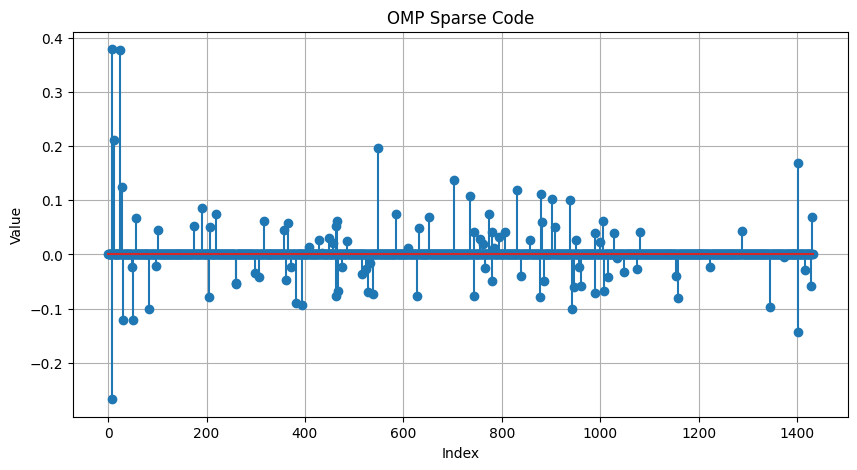

In [13]:
# Plot the sparse codes
plot_solution(sparse_code_omp, title="OMP Sparse Code")

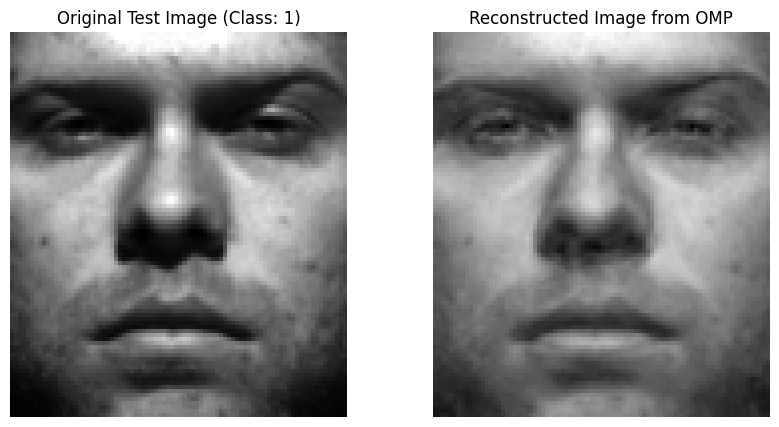

In [14]:
# Plot the test image and the reconstructed image from OMP
reconstructed_image_omp = dictionary @ sparse_code_omp
reconstructed_image_omp = reconstructed_image_omp.reshape(X_train.shape[1], X_train.shape[2])  # Reshape to original image dimensions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
plt.title(f"Original Test Image (Class: {test_image_label})")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image_omp, cmap='gray')
plt.title("Reconstructed Image from OMP")
plt.axis('off')
plt.show()

We can get prettey good reconstruction just using 100 iterations of OMP.

In [15]:
# To find the predicted class, we can look at the non-zero coefficients and their corresponding class labels.
# For each class, we mask the coefficients that does not belong to that class and compute the residual error. The class with the smallest residual error can be considered as the predicted class.

def compute_residual_error(test_image, dictionary, class_id):
    """
    Resconstruct the image using only the coefficients that belong to the specified class and compute the residual error.

    Parameters:
    test_image (numpy array): The original test image (vectorized).
    dictionary (numpy array): The dictionary of training images (shape: num_features x num_train_samples).
    class_id (int): The class ID for which to compute the residual error.
    Returns:
    residual_error (float): The computed residual error for the specified class.
    reconstructed_image (numpy array): The reconstructed image using the coefficients of the specified class.
    """
    # Create a mask for the current class
    class_mask = (y_train == class_id)

    # Mask the coefficients that do not belong to the current class
    masked_sparse_code = np.copy(sparse_code_omp)
    masked_sparse_code[~class_mask] = 0

    # Reconstruct the image using the masked sparse code
    reconstructed_image = dictionary @ masked_sparse_code

    # Compute the residual error
    residual_error = np.linalg.norm(test_image - reconstructed_image)

    reconstructed_image = reconstructed_image.reshape(X_train.shape[1], X_train.shape[2])  # Reshape to original image dimensions

    return residual_error, reconstructed_image


def predict_class(sparse_code, dictionary, y_train, test_image):
    unique_classes = np.unique(y_train)
    residuals = {}

    for cls in unique_classes:
        # 1. Get a boolean mask for where the current class is located
        class_mask = (y_train == cls)

        # 2. SLICE the dictionary and the code. No zeros are used here!
        # If class 1 has 64 images, dict_class is now (8064, 64) instead of (8064, 2400)
        dict_class = dictionary[:, class_mask]
        code_class = sparse_code[class_mask]

        # 3. Reconstruct the image using ONLY the subset
        # This requires ~500k operations instead of ~19.3 million
        reconstructed_image = dict_class @ code_class

        # 4. Compute the residual error
        residual_error = np.linalg.norm(test_image - reconstructed_image)
        residuals[cls] = residual_error

    # Find the class with the smallest residual error
    predicted_class = min(residuals, key=residuals.get)
    return predicted_class, residuals

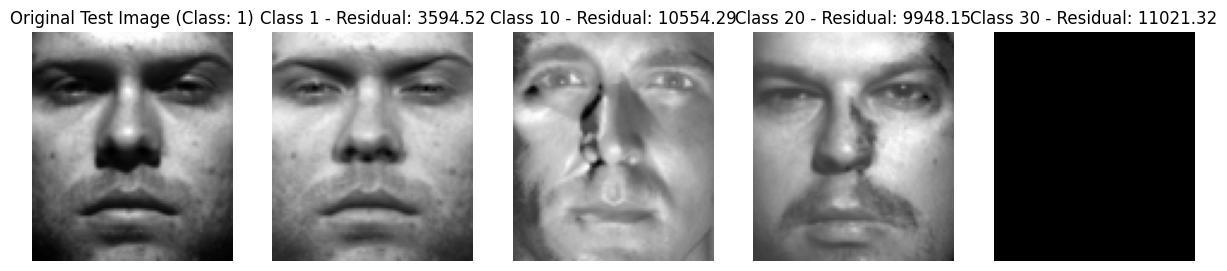

In [16]:
# Compare the reconstructed image with the original test image and compute the residual error for a few classes
classes_to_compare = [1, 10, 20, 30]  # Example class IDs to compare
figure, axes = plt.subplots(1, len(classes_to_compare) + 1, figsize=(15, 5))
axes[0].imshow(test_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
axes[0].set_title(f"Original Test Image (Class: {test_image_label})")
axes[0].axis('off')
for i, cls in enumerate(classes_to_compare):
    residual_error, reconstructed_image = compute_residual_error(test_image, dictionary, cls)
    axes[i + 1].imshow(reconstructed_image, cmap='gray')
    axes[i + 1].set_title(f"Class {cls} - Residual: {residual_error:.2f}")
    axes[i + 1].axis('off')
plt.show()

Predicted class using OMP: 1


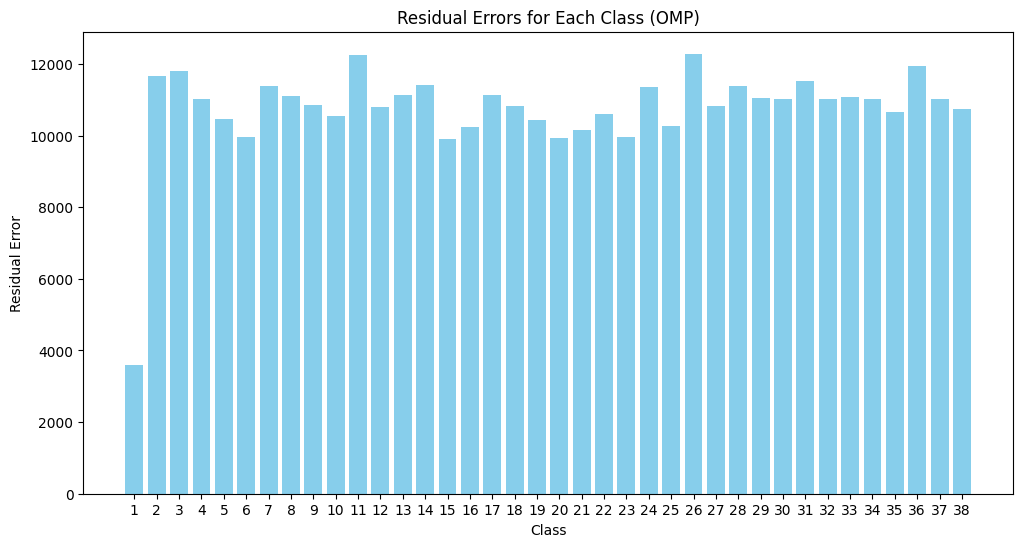

In [18]:
# Predict the class of the test image using OMP coefficients
predicted_class_omp, residuals_omp = predict_class(sparse_code_omp, dictionary, y_train, test_image)
print(f"Predicted class using OMP: {predicted_class_omp}")

# Plot the residual errors for all classes
plt.figure(figsize=(12, 6))
plt.bar(residuals_omp.keys(), residuals_omp.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Residual Error')
plt.title('Residual Errors for Each Class (OMP)')
plt.xticks(list(residuals_omp.keys()))
plt.show()

In [ ]:
# Test all test images and compute the overall accuracy
correct_predictions_omp = 0
for i in tqdm(range(X_test.shape[0])):
    test_image = X_test[i, :, :].flatten()
    test_image_label = y_test[i]

    # Compute the sparse code for the test image using OMP
    sparse_code_omp = solve_orthogonal_matching_pursuit(dictionary, test_image, max_iter=100)

    # Predict the class using the computed sparse code
    predicted_class_omp, _ = predict_class(sparse_code_omp, dictionary, y_train, test_image)

    if predicted_class_omp == test_image_label:
        correct_predictions_omp += 1

# Compute the overall accuracy
accuracy_omp = correct_predictions_omp / X_test.shape[0]
print(f"Overall accuracy using OMP: {accuracy_omp:.4f}")

The algorithm achieve 99.6% accuracy. However it took a long time to run prediction of the entire test set on my machine. I think to move on the next part we might need to optimize the algorithm.

This cell is not rerun to save time.

Running time for OMP using sklearn: 0.4226 seconds
Predicted class using sklearn OMP: 1


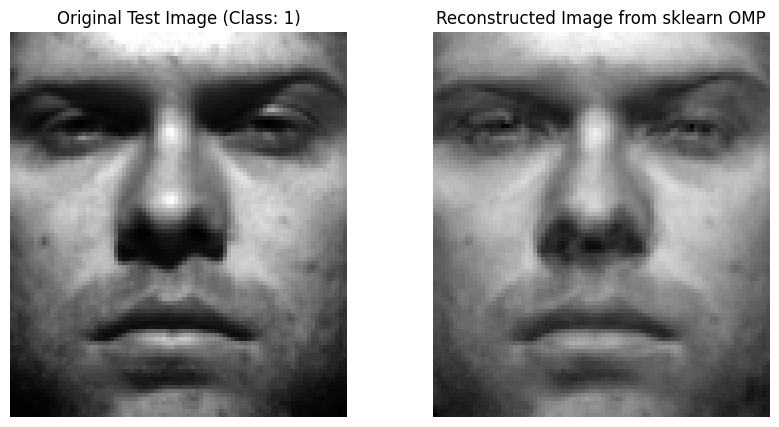

Running time for OMP using our implementation: 4.9384 seconds
Predicted class using our OMP implementation: 1


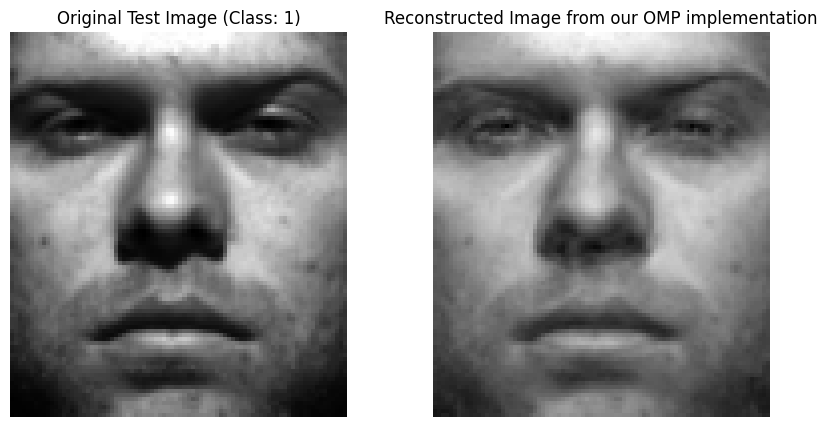

In [20]:
# We use the sklearn library built-in function for OMP and compare running time with our implementation on the first test image
import time
from sklearn.linear_model import OrthogonalMatchingPursuit

# The first test image and its label
test_image = X_test[0, :, :].flatten()
test_image_label = y_test[0]

# Initialize the OMP model from sklearn
omp_model = OrthogonalMatchingPursuit(n_nonzero_coefs=100)  # Set the maximum number of non-zero coefficients to 100 for a fair comparison with our implementation

# Fit the OMP model to the dictionary and the test image
start_time = time.time()
omp_model.fit(dictionary, test_image)
end_time = time.time()
print(f"Running time for OMP using sklearn: {end_time - start_time:.4f} seconds")

# Get the sparse code from the fitted model
sparse_code_sklearn = omp_model.coef_
# Predict the class using the sparse code from sklearn OMP
predicted_class_sklearn, _ = predict_class(sparse_code_sklearn, dictionary, y_train, test_image)
print(f"Predicted class using sklearn OMP: {predicted_class_sklearn}")

# Plot the reconstructed image from sklearn OMP
reconstructed_image_sklearn = dictionary @ sparse_code_sklearn
reconstructed_image_sklearn = reconstructed_image_sklearn.reshape(X_train.shape[1], X_train.shape[2])  # Reshape to original image dimensions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
plt.title(f"Original Test Image (Class: {test_image_label})")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image_sklearn, cmap='gray')
plt.title("Reconstructed Image from sklearn OMP")
plt.axis('off')
plt.show()

# Compare with our implementation of OMP

start_time = time.time()
sparse_code_omp = solve_orthogonal_matching_pursuit(dictionary, test_image, max_iter=100)
end_time = time.time()
print(f"Running time for OMP using our implementation: {end_time - start_time:.4f} seconds")
predicted_class_omp, _ = predict_class(sparse_code_omp, dictionary, y_train, test_image)
print(f"Predicted class using our OMP implementation: {predicted_class_omp}")

# Plot the reconstructed image from our OMP implementation
reconstructed_image_omp = dictionary @ sparse_code_omp
reconstructed_image_omp = reconstructed_image_omp.reshape(X_train.shape[1], X_train.shape[2])  # Reshape to original image dimensions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
plt.title(f"Original Test Image (Class: {test_image_label})")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image_omp, cmap='gray')
plt.title("Reconstructed Image from our OMP implementation")
plt.axis('off')
plt.show()


The sklearn OMP implementation was much faster than my implementation.

In [21]:
# Test all test images and compute the overall accuracy for sklearn OMP
correct_predictions_sklearn_omp = 0

start_time = time.time()
# Predict in batch for sklearn OMP to save time
omp_model.fit(dictionary, X_test.reshape(X_test.shape[0], -1).T)  # Fit the model to the entire test set
sparse_codes_sklearn = omp_model.coef_  # Get the sparse codes for
for i in tqdm(range(X_test.shape[0])):
    test_image = X_test[i, :, :].flatten()
    test_image_label = y_test[i]

    # Get the sparse code for the current test image from the batch prediction
    sparse_code_sklearn = sparse_codes_sklearn[i, :]

    # Predict the class using the computed sparse code
    predicted_class_sklearn, _ = predict_class(sparse_code_sklearn, dictionary, y_train, test_image)

    if predicted_class_sklearn == test_image_label:
        correct_predictions_sklearn_omp += 1

accuracy_sklearn_omp = correct_predictions_sklearn_omp / X_test.shape[0]
end_time = time.time()
print(f"Running time for predicting all test images using sklearn OMP: {end_time - start_time:.4f} seconds")
print(f"Overall accuracy for sklearn OMP: {accuracy_sklearn_omp:.4f}")

100%|██████████| 981/981 [00:24<00:00, 40.30it/s]

Running time for predicting all test images using sklearn OMP: 40.8166 seconds
Overall accuracy for sklearn OMP: 0.9949


The entire dataset ran in just 23 seconds on my machine, accuracy achieved is 99.5%

# Part 2
Improve your SRC face-recognition algorithm so that it can handle sparse outliers: random pixel corruptions and random patch corruptions. Purposely add sparse outliers to your test images and repeat your experiment above. Plot your classiﬁcation accuracy as a function of corruption percentage.

In [23]:
# Make a robust dictionary by adding an indentity matrix with size (dictionary.shape[0], dictionary.shape[0]) to the original dictionary.
identity_matrix = np.eye(dictionary.shape[0])
robust_dictionary = np.hstack((dictionary, identity_matrix))
robust_dictionary.shape

(8064, 9497)

In [24]:
noise_labels = np.full((identity_matrix.shape[1],), fill_value=-1)  # Label for noise components
robust_labels = np.concatenate((y_train, noise_labels))  # Combine original labels with noise labels
robust_labels.shape

(9497,)

In [25]:
# Function to corrupt an image with spatially coherent noise (a fast Perlin proxy)
from scipy.ndimage import gaussian_filter

def corrupt_image(image_flat, image_shape=(96, 84), corruption_rate=0.2, sigma=3.0):
    """
    Corrupts an image using spatially coherent noise (a fast Perlin proxy).

    Parameters:
    image_flat (np.ndarray): 1D array of the flattened image.
    image_shape (tuple): The original 2D shape of the image (e.g., (96, 84)).
    corruption_rate (float): Percentage of pixels to corrupt (0.0 to 1.0).
    sigma (float): Controls the blur radius. Higher = larger, softer blobs.

    Returns:
    np.ndarray: The corrupted flattened image.
    """
    # 1. Generate pure random static (white noise) in 2D
    white_noise = np.random.rand(*image_shape)

    # 2. Smooth the noise to create spatially contiguous blobs (Perlin proxy)
    smoothed_noise = gaussian_filter(white_noise, sigma=sigma)

    # 3. Flatten to match the input image
    noise_flat = smoothed_noise.flatten()

    # 4. Find the threshold to hit the exact corruption percentage
    threshold = np.percentile(noise_flat, corruption_rate * 100)

    # 5. Create the mask and apply it
    mask = noise_flat > threshold

    corrupted_image = image_flat.copy()
    corrupted_image[~mask] = 0

    return corrupted_image

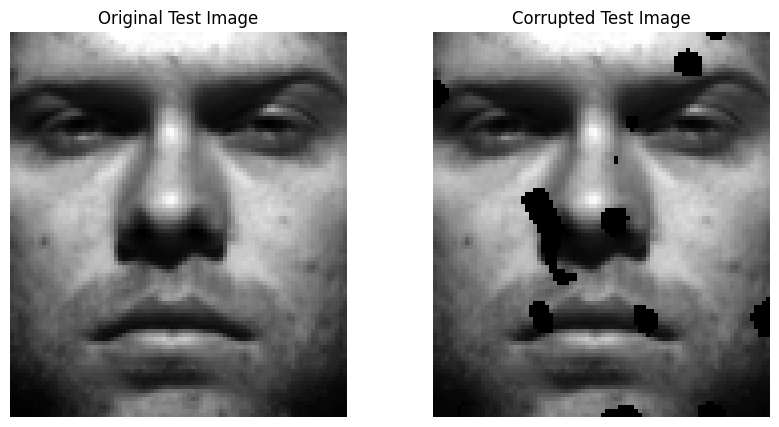

In [26]:
# Test the corruption function on a sample test image
sample_test_image = X_test[0, :, :].flatten()
corrupted_image = corrupt_image(sample_test_image, image_shape=(96, 84), corruption_rate=0.05, sigma=3.0)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_test_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
plt.title("Original Test Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(corrupted_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
plt.title("Corrupted Test Image")
plt.axis('off')
plt.show()

In [27]:
# Apply it over the test set to create a corrupted test set

list_corrupted_test_sets = []
corruption_levels = [0.1, 0.2, 0.3, 0.4, 0.5]  # Example corruption levels

for corruption_level in corruption_levels:
    corrupted_test_set = np.array([corrupt_image(X_test[i, :, :].flatten(), corruption_rate=corruption_level) for i in range(X_test.shape[0])])
    list_corrupted_test_sets.append(corrupted_test_set)

Running time for OMP with robust dictionary: 6.7518 seconds
Predicted class for the corrupted test image using OMP with robust dictionary: 1


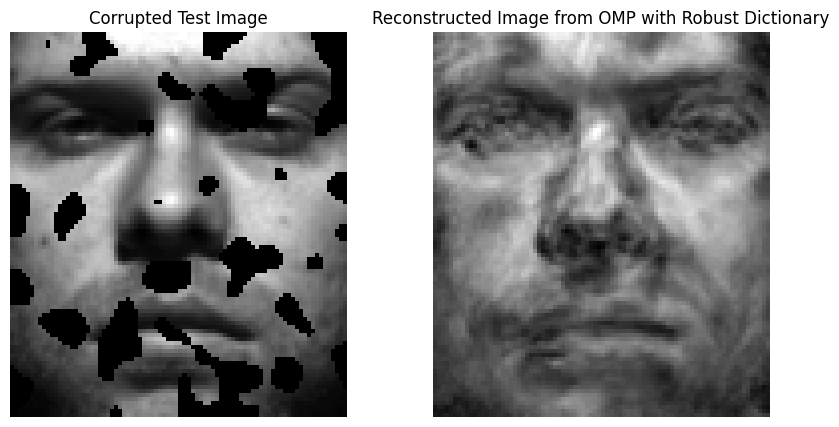

In [28]:
# Test and time on one corrupted test image
corrupted_test_image = list_corrupted_test_sets[1][0, :]  # Get the first image from the second corruption level (20% corruption)
start_time = time.time()
omp_model.fit(robust_dictionary, corrupted_test_image)  # Fit the model to the corrupted test image
sparse_code_omp = omp_model.coef_  # Get the sparse code for the
predicted_class_omp, _ = predict_class(sparse_code_omp, robust_dictionary, robust_labels, corrupted_test_image)
end_time = time.time()
print(f"Running time for OMP with robust dictionary: {end_time - start_time:.4f} seconds")
print(f"Predicted class for the corrupted test image using OMP with robust dictionary: {predicted_class_omp}")

# Plot the reconstructed image from OMP with the robust dictionary
reconstructed_image_omp = robust_dictionary @ sparse_code_omp
reconstructed_image_omp = reconstructed_image_omp.reshape(X_train.shape[1], X_train.shape[2])  # Reshape to original image dimensions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(corrupted_test_image.reshape(X_train.shape[1], X_train.shape[2]), cmap='gray')
plt.title("Corrupted Test Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image_omp, cmap='gray')
plt.title("Reconstructed Image from OMP with Robust Dictionary")
plt.axis('off')
plt.show()

2 seconds for one image is still over 30 minutes for 981 images in the dataset. To run all will still take a long time.

After a bit of researching, I found this package, [Batched OMP: Fast Orthogonal Matching Pursuit for CPU and GPU](https://github.com/ariellubonja/orthogonal-matching-pursuit-gpu), that says they achieved 300 times speed up compare to scikitlearn on GPU.

Citing their paper here **Lubonja, A., Präsius, S. K., & Tran, T. D. (2024). Efficient batched CPU/GPU implementation of orthogonal matching pursuit for Python. *arXiv preprint arXiv:2407.06434*.**

The last author's name sounds very familiar.

To fully utilize the library power, the later part of this notebook is run on Google Colab to make use of GPU.

In [31]:
import numpy as np
import torch
import time
from batched_omp import run_omp

# 1. Convert to float32! This fixes the "Got: Byte" error.
D_float = robust_dictionary.astype(np.float32)
y_float = corrupted_test_image.astype(np.float32)

# 2. Reshape to (1, n_features) to simulate a "batch" of 1 image
if y_float.ndim == 1:
    y_float = y_float.reshape(1, -1)

# 3. Move them to the GPU (T4 on Colab)
D_tensor = torch.tensor(D_float).cuda()
y_tensor = torch.tensor(y_float).cuda()

start_time = time.time()

# 4. Run the GPU optimized solver
sparse_code_batch = run_omp(D_tensor, y_tensor, n_nonzero_coefs=100)

# 5. Bring back to CPU and flatten it back to 1D for your predict_class function
sparse_code_omp = sparse_code_batch.cpu().numpy().flatten()

# Note: Pass the original 1D corrupted_test_image here
predicted_class_omp, _ = predict_class(sparse_code_omp, robust_dictionary, robust_labels, corrupted_test_image)

end_time = time.time()
print(f"Running time for batched OMP (1 image): {end_time - start_time:.4f} seconds")
print(f"Predicted class: {predicted_class_omp}")

Running time for batched OMP (1 image): 1.2653 seconds
Predicted class: 1


In [33]:
# Run it on all test sets

# 1. Prepare the dictionary once to save time
# Convert to float32 and move to GPU
D_tensor = torch.tensor(robust_dictionary.astype(np.float32)).cuda()

results = {}

for i, corrupted_test_set in enumerate(list_corrupted_test_sets):
    correct_predictions_omp = 0

    # 2. Prepare the current batch of corrupted test images
    # Shape of corrupted_test_set should be (n_samples, n_features)
    y_batch = corrupted_test_set.astype(np.float32)
    y_tensor = torch.tensor(y_batch).cuda()

    print(f"\n--- Processing Corruption Level {corruption_levels[i]:.1f} ---")
    start_time = time.time()

    # 3. RUN BATCHED OMP ON THE ENTIRE TEST SET ON THE GPU
    # This replaces batch_omp_model.fit(...)
    # Output shape: (n_samples, n_components) -> (981, 9497)
    sparse_codes_tensor = run_omp(D_tensor, y_tensor, n_nonzero_coefs=100)

    # Bring the computed sparse codes back to the CPU for evaluation
    sparse_codes_omp = sparse_codes_tensor.cpu().numpy()

    gpu_time = time.time() - start_time
    print(f">> GPU Batched OMP solved {y_batch.shape[0]} images in {gpu_time:.4f} seconds!")

    # 4. FULLY BATCHED RESIDUAL CALCULATION
    # We only want to predict human classes, so ignore the -1 noise class
    valid_classes = np.unique(y_train)
    num_classes = len(valid_classes)
    num_test_images = y_batch.shape[0]

    # Matrix to store the error of every class for every image
    # Shape: (38 classes, 981 test images)
    all_residuals = np.zeros((num_classes, num_test_images))

    # We loop over the 38 classes, NOT the 981 images!
    for idx, cls in enumerate(valid_classes):
        class_mask = (robust_labels == cls)

        # Extract dictionary and codes for THIS class only
        D_c = robust_dictionary[:, class_mask]   # Shape: (8064, N_c)
        X_c = sparse_codes_omp[:, class_mask]    # Shape: (981, N_c)

        # Matrix math magic: Reconstruct ALL 981 images at once for this class
        # X_c @ D_c.T multiplies (981, N_c) x (N_c, 8064) -> (981, 8064)
        Recon_c = X_c @ D_c.T

        # Calculate the residual error for ALL 981 images at once
        # Diff is (981, 8064). We take the norm across the pixel axis (axis 1)
        diff = y_batch - Recon_c
        errors = np.linalg.norm(diff, axis=1)    # Shape: (981,)

        # Store these 981 errors
        all_residuals[idx, :] = errors

    # Find the index of the class with the lowest error for each of the 981 columns
    best_class_indices = np.argmin(all_residuals, axis=0)

    # Map those indices back to the actual class labels (e.g., 1 to 38)
    predicted_classes = valid_classes[best_class_indices]

    # Calculate accuracy instantly
    correct_predictions_omp = np.sum(predicted_classes == y_test)
    accuracy_omp = correct_predictions_omp / num_test_images

    results[corruption_levels[i]] = accuracy_omp
    print(f"Evaluating Level {corruption_levels[i]:.1f} complete!")
    print(f"Corruption level: {corruption_levels[i]:.1f}, OMP Accuracy: {accuracy_omp:.4f}\n")


--- Processing Corruption Level 0.1 ---
>> GPU Batched OMP solved 981 images in 2.7530 seconds!
Evaluating Level 0.1 complete!
Corruption level: 0.1, OMP Accuracy: 0.9888


--- Processing Corruption Level 0.2 ---
>> GPU Batched OMP solved 981 images in 2.7801 seconds!
Evaluating Level 0.2 complete!
Corruption level: 0.2, OMP Accuracy: 0.9480


--- Processing Corruption Level 0.3 ---
>> GPU Batched OMP solved 981 images in 2.7895 seconds!
Evaluating Level 0.3 complete!
Corruption level: 0.3, OMP Accuracy: 0.8858


--- Processing Corruption Level 0.4 ---
>> GPU Batched OMP solved 981 images in 2.7836 seconds!
Evaluating Level 0.4 complete!
Corruption level: 0.4, OMP Accuracy: 0.7482


--- Processing Corruption Level 0.5 ---
>> GPU Batched OMP solved 981 images in 2.7724 seconds!
Evaluating Level 0.5 complete!
Corruption level: 0.5, OMP Accuracy: 0.5617



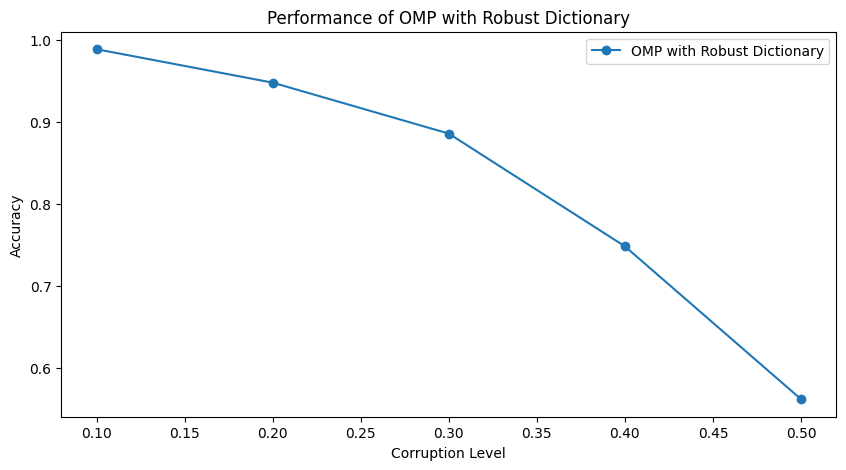

In [34]:
# Plot the accuracy results for OMP with the robust dictionary
plt.figure(figsize=(10, 5))
plt.plot(corruption_levels, [results[cl] for cl in corruption_levels], marker='o', label='OMP with Robust Dictionary')
plt.xlabel('Corruption Level')
plt.ylabel('Accuracy')
plt.title('Performance of OMP with Robust Dictionary')
plt.legend()
plt.show()

It is amazing that the batched omp library can do OMP of 981 images in less than 3 seconds while my implementation would have taken hours. Even the scikitlearn OMP would take over 30 minutes.